### ☀️ 참고 ☀️ 한글깨짐 방지

- 아래 코드셀 3개 실행 필수
- 윈도우, 맥 동일

❗️주의❗️
- Step1. 첫째 셀 실행
- Step2. '런타임 > 세션 다시시작'
- Step3. 이후 두번째 셀 실행

In [11]:
# 나눔 폰트 설치
# 해당 셀 실행 후 '런타임 > 세션 다시 시작'

# %%capture

# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl


# 나눔고딕 폰트 사용 설정 (폰트 설치 후 실행)
plt.rcParams["font.family"]="NanumGothic"

# 마이너스 깨짐 방지 (일반 하이픈(-)을 사용하게 설정)
mpl.rcParams['axes.unicode_minus'] = False

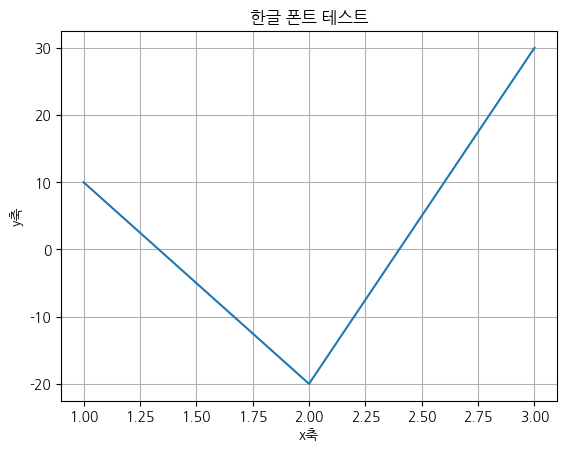

In [13]:
# 한글 폰트 테스트 그래프

plt.plot([1, 2, 3], [10, -20, 30])
plt.title('한글 폰트 테스트')
plt.xlabel('x축')
plt.ylabel('y축')
plt.grid(True)
plt.show()

# 📘 CH03-01. 머신러닝 기초 — 실습 노트북

> 🔄 **개정 안내**: 개념 설명(기초수학, 지도/비지도/강화학습, 데이터 분할의 원리)은 별도 프레젠테이션 자료로 먼저 진행합니다. 이 노트북은 그 개념을 **직접 손으로 확인하고 적용하는 실습**에 집중합니다.
>
> 이번 개정판의 핵심은 **2라운드 연습 구조**입니다. 모든 핵심 개념을 **Round 1: 일상 이야기로 손에 익히기 → Round 2: 머신러닝 상황에 그대로 적용하기** 순서로 두 번씩 연습합니다. 한 번 해보고 넘어가는 것이 아니라, 같은 원리를 다른 상황에서 한 번 더 써보며 "아, 이게 그거구나"라는 감각을 만드는 것이 목표입니다.
>
> TODO 실습과 실습 과제는 **자습 시간**에 진행합니다.

# 📘 CH03-01-01. 기초수학 — 눈으로 직접 확인하기

━━━━━━━━━━━━━━━━

> 🗂️ **구성**: (개념은 프레젠테이션 참고) → 내적 Round 1·2 (카페 계산 → 예측 모델) → 경사하강법 Round 1·2 (키 맞히기 게임 → 자동화·학습률 실험) → Check Point
> ⏱️ **예상 소요시간**: 60분
> 🎚️ **난이도**: ★★★☆☆

---

## 🤔 워밍업

> "머신러닝을 하려면 수학을 잘해야 하나요?" — 오늘 필요한 수학은 딱 두 가지입니다. **① 곱해서 더하기(내적)**, **② 틀린 만큼 조금씩 고치기(경사하강법)**.

> 둘 다 여러분이 카페에서 계산할 때, 업다운 게임을 할 때 이미 쓰고 있는 사고방식입니다. 지금까지 어렵게 느껴졌다면 그건 수식 기호 때문이지, 아이디어 자체 때문이 아닙니다. 오늘 그걸 눈으로 직접 확인합니다.

### 1) 벡터와 내적 — Round 1: 카페 사장님의 계산기

> ☕ **상황**: 여러분이 작은 카페 사장님이라고 해봅시다. 오늘 아메리카노 3잔, 라떼 2잔, 쿠키 4개가 팔렸습니다. 오늘 총매출은 얼마일까요? 누구나 이렇게 계산합니다.
>
> ```
> 총매출 = 3잔 × 4,500원 + 2잔 × 5,000원 + 4개 × 2,000원
> ```
>
> **짝끼리 곱해서, 전부 더한다.** — 이 흔한 계산에 이름을 붙인 것이 바로 **내적(dot product)** 입니다. 새로운 수학이 아니라, 이미 아는 계산에 이름표만 붙이는 겁니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import numpy as np

# ☕ 오늘 팔린 개수 — 이렇게 숫자를 순서대로 묶어놓은 것을 "벡터"라고 부릅니다
sold = np.array([3, 2, 4])            # [아메리카노 3잔, 라떼 2잔, 쿠키 4개]

# 💰 메뉴별 가격 — 이것도 벡터 (순서가 위와 짝이 맞아야 합니다!)
price = np.array([4500, 5000, 2000])  # [아메리카노, 라떼, 쿠키]의 가격

# 방법 1: 우리가 늘 하던 손 계산
by_hand = 3 * 4500 + 2 * 5000 + 4 * 2000

# 방법 2: 내적(dot product) — "짝끼리 곱해서 전부 더하기"를 한 줄로
total = np.dot(sold, price)

print("손으로 계산한 총매출:", by_hand, "원")
print("내적으로 계산한 총매출:", total, "원")
```

</details>

In [14]:
# 코드 입력

import numpy as np

# 벡터: 숫자를 순서대로 묶어놓은 것. 1차원 데이터
sold = np.array([3,2,4])  # 판매건수
price = np.array([4500,5000,2000])  # 판매가격

# 방법 1: 우리가 늘 하던 손계산
by_hand = 3 * 4500 + 2 * 5000 + 4 * 2000

# 만약 변수가 100만 개면?
# 방법 2: 내적 (dot product)
total = np.dot(sold, price)

print(by_hand,'원')
print(total,'원')

31500 원
31500 원


> 🔮 **예측해보세요**: 실행하기 전에 — 두 값이 같을까요, 다를까요? 내적이 정말 "짝끼리 곱해서 더하기"라면 당연히 같아야겠죠.

> 💡 **내적 = 짝끼리 곱해서 전부 더하기.** 메뉴가 3개든 300개든 `np.dot()` 한 줄이면 끝납니다. 머신러닝에서 특성(feature)이 수백 개여도 계산이 복잡해지지 않는 이유가 바로 이것입니다.

### Round 2: 같은 계산이 곧 "예측"이 됩니다 — 배달 라이더 수입 예측기

> 🛵 **상황**: 배달 라이더의 하루 수입이 "배달 건수 × 건당 3,000원 + 이동거리(km) × km당 100원"으로 정해진다고 해봅시다. 어라? 이것도 **짝끼리 곱해서 더하기** — 내적입니다.
>
> 머신러닝의 선형 모델이 예측값을 만드는 방식이 정확히 이것입니다. 카페 계산과 딱 하나 다른 점은 — 카페에서는 가격표를 **사람**이 정하지만, 머신러닝에서는 가격표에 해당하는 **가중치(weight)를 컴퓨터가 데이터를 보고 스스로 찾아낸다**는 것뿐입니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 🛵 라이더 한 명의 오늘 기록 = 특성(feature) 벡터
rider = np.array([30, 120])           # [배달 30건, 이동거리 120km]

# 머신러닝에서는 '단가표'를 가중치(weight)라고 부릅니다
weights = np.array([3000, 100])       # [건당 3000원, km당 100원]

# 예측 수입 = 특성 벡터와 가중치 벡터의 내적 (카페 계산과 완전히 같은 구조!)
income = np.dot(rider, weights)
print("오늘 예상 수입:", income, "원")
```

</details>

In [15]:
# 코드 입력

# 특성(feature) 벡터
rider = np.array([30,120])      # 배달 건수 30건, 이동거리 120km

# 가중치(w)
weights = np.array([3000,100])  # 건단 3000원, km당 100원

# 예측 수입 = 특성 벡터와 가중치 벡터의 내적
income = np.dot(rider, weights)
print('오늘 예상 수입:', income)


오늘 예상 수입: 102000


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 라이더가 3명이라면? 특성 벡터를 3줄로 쌓으면 됩니다 (이런 표 모양을 "행렬"이라 부릅니다)
riders = np.array([
    [30, 120],    # 1번 라이더: 30건, 120km
    [25,  90],    # 2번 라이더: 25건,  90km
    [40, 150],    # 3번 라이더: 40건, 150km
])

# @ 기호는 "각 줄(라이더)마다 내적을 한꺼번에 계산해줘"라는 뜻입니다
incomes = riders @ weights
print("세 명의 예상 수입:", incomes, "원")
```

</details>

In [16]:
# 라이더가 3명이라면?
# 1번: 30건, 120km
# 2번: 25건, 90km
# 3번: 40건, 150km

riders = np.array([
    [30,120],
    [25,90],
    [40,150]
])

incomes = np.dot(riders, weights)
print(incomes)

# @: 행렬 곱 연산자 (파이썬 3.5부터 추가)
# @ 기호는 "각 줄(라이더)마다 내적을 한꺼번에 계산해줘"라는 뜻입니다
#incomes = np.dot(riders, weights) 과 완전히 동일

incomes = riders @ weights
print(incomes)


[102000  84000 135000]
[102000  84000 135000]


> 🚀 **실무에서는?** 선형 회귀, 로지스틱 회귀, 심지어 딥러닝의 한 층(layer)까지 — 예측 계산의 뼈대는 전부 `특성 · 가중치` 내적입니다. 그렇다면 좋은 가중치는 어떻게 찾을까요? 그것이 바로 다음 주제, 경사하강법입니다.

### 2) 경사하강법 — Round 1: 키 맞히기 업다운 게임 (손으로 한 스텝씩)

> 🎯 **상황**: 친구의 키를 맞히는 게임을 합니다. 친구의 **실제 키는 170cm**, 나의 **첫 예측은 150cm**입니다. 얼마나 틀렸는지 벌점(손실, loss)을 매기고, 틀린 방향의 **반대로 조금씩** 예측을 고쳐 나갑니다. 이 단순한 업다운 게임이 경사하강법의 전부입니다.
>
> ```
> 실제 키   = 170cm
> 현재 예측 = 150cm
>
> loss = (150 - 170)² = (-20)² = 400   ← "얼마나 틀렸나"를 점수로
> ```
>
> ❓ 왜 그냥 -20이 아니라 **제곱**을 할까요?
> ① 제곱하면 음수가 사라져서 "20 모자람"과 "20 넘침"을 같은 크기의 벌점으로 다룰 수 있고,
> ② 크게 틀릴수록 벌점이 훨씬 커지므로(10 틀림→100점, 20 틀림→400점) 큰 실수부터 고치게 됩니다.

### MSE, Mean Squared Error (평균제곱오차)
> 경사하강법으로 학습하기에 가장 다루기 쉬운 손실 함수

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
$$

[장점]
1) 어디서나 미분이 가능하다. ✅
2) 그래프가 매끄럽다. ✅
3) 경사하강법이 어느 방향으로 얼마나 4) 움직여야 하는지 계산하기 쉽다. ✅
5) 오차가 클수록 더 큰 벌점을 주므로 큰 실수를 빨리 수정한다. ✅

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
actual = 170     # 친구의 실제 키 (정답)
guess = 150      # 나의 현재 예측
lr = 0.1         # 학습률(learning rate): 한 번에 얼마나 크게 고칠지 (일단 0.1)

# ① 지금 얼마나 틀렸나? = 손실(loss)
loss = (guess - actual) ** 2
print(f"현재 예측 {guess}cm | loss = ({guess} - {actual})² = {loss}")

# ② 기울기(gradient): loss = (guess - actual)² 을 미분하면 2 × (guess - actual)
#    미분이 낯설어도 괜찮습니다. "어느 방향으로 얼마나 틀렸는지 알려주는 신호"라고 생각하세요.
gradient = 2 * (guess - actual)
print(f"기울기 = 2 × ({guess} - {actual}) = {gradient}")
print("기울기가 음수 → '예측이 정답보다 작다, 키워라!'라는 신호입니다")
```

</details>

In [17]:
# 코드 입력

actual = 170
guess = 150

lr = 0.1  # 학습률(한 번에 얼마나 크게 고칠지)

# ① 지금 얼마나 틀렸나? = 손실(loss)
# 데이터가 1개이므로 MSE가 아니라 하나의 loss를 계산
loss = (guess - actual) ** 2
print(f'현재 예측 {guess}cm | loss ({guess} - {actual})^2 = {loss}')


현재 예측 150cm | loss (150 - 170)^2 = 400


In [18]:
# ② 기울기(gradient)
# loss = (guess - actual)² 을 미분하면 2 × (guess - actual)

gradient = 2 * (guess - actual)
print(gradient)

# 기울기가 음수 -> 예측이 정답보다 작다, 키워라! 라는 의미


-40


> 🔮 **예측해보세요**: 경사하강법의 규칙은 `새 예측 = 현재 예측 - 학습률 × 기울기` 입니다. 그럼 1스텝 후의 예측은? 150 - 0.1 × (-40)을 암산으로 먼저 구해보고 아래 실행 결과와 비교해보세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 경사하강법의 유일한 규칙: "기울기의 반대 방향으로 조금 이동"
#   새 예측 = 현재 예측 - 학습률 × 기울기

guess = 150
for step in range(1, 6):                     # 딱 5스텝만 손으로 따라가 봅니다
    gradient = 2 * (guess - actual)          # ① 지금 위치에서 어느 방향으로 틀렸나
    guess = guess - lr * gradient            # ② 그 반대 방향으로 한 걸음
    loss = (guess - actual) ** 2             # ③ 얼마나 가까워졌나 확인
    print(f"{step}스텝: 예측 {guess:.1f}cm | loss {loss:.1f}")
```

</details>

In [19]:
# 경사하강법의 유일한 규칙: "기울기의 반대 방향으로 조금 이동"
# 새 예측 = 현재 예측 - 학습률 × 기울기

guess = 150

for step in range(1,6):
    gradient = 2 * (guess - actual) # 기울기 구하기
    guess = guess - lr * gradient   # 경사하강법 (반대로 한걸음)
    loss = (guess - actual) ** 2    # 손실 확인
    print(f'{step}스텝: 예측 {guess:.1f}cm, loss 손실: {loss:.2f}')



1스텝: 예측 154.0cm, loss 손실: 256.00
2스텝: 예측 157.2cm, loss 손실: 163.84
3스텝: 예측 159.8cm, loss 손실: 104.86
4스텝: 예측 161.8cm, loss 손실: 67.11
5스텝: 예측 163.4cm, loss 손실: 42.95


> 💡 스텝을 거듭할수록 예측이 170에 가까워지고 loss가 0을 향해 줄어드는 것이 보이시나요? **"틀린 만큼, 반대 방향으로, 조금씩"** — 모델이 '학습한다'는 말의 실체가 바로 이것입니다. 실제 모델은 이 업다운 게임을 가중치 수백만 개에 대해 동시에 할 뿐입니다.

### Round 2: 자동화 + 학습률 실험 — 보폭이 너무 크면 무슨 일이?

이제 손 계산을 함수 하나로 자동화하고, **학습률(learning_rate)만 바꿔가며** 무슨 일이 생기는지 관찰합니다. 이번 챕터의 핵심 실험입니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
def gradient_descent(learning_rate, steps=20, start=150, target=170):
    """start(첫 예측)에서 출발해 target(정답)을 향해 조금씩 다가가는 과정을 기록합니다"""
    guess = start
    history = [guess]                              # 예측이 변해가는 과정을 저장
    for _ in range(steps):
        gradient = 2 * (guess - target)            # 지금 어느 방향으로, 얼마나 틀렸나
        guess = guess - learning_rate * gradient   # 반대 방향으로 한 걸음
        history.append(guess)
    return history

history = gradient_descent(learning_rate=0.1)
print("최종 예측:", round(history[-1], 2), "cm")
print("처음 5스텝:", [round(h, 1) for h in history[:5]])
```

</details>

In [20]:
def gradient_descent(learning_rate, steps=20, start=150, target=170):
    """start(첫 예측)에서 출발해 target(정답)을 향해 조금씩 다가가는 과정을 기록합니다"""
    # 코드 입력

    guess = start
    history = [guess]

    # _ : 변수와는 상관 없이 단순 횟수만 반복하기
    for _ in range(steps):
        gradient = 2 * (guess - target)
        guess = guess - learning_rate * gradient
        history.append(guess)
    return history

history = gradient_descent(learning_rate=0.1)
print("최종 예측:", round(history[-1], 2), "cm")
print("처음 5스텝:", [round(h, 1) for h in history[:5]])

최종 예측: 169.77 cm
처음 5스텝: [150, 154.0, 157.2, 159.8, 161.8]


> 🔮 **예측해보세요**: 학습률을 0.1보다 훨씬 크게(예: 1.05) 주면 예측이 170으로 잘 수렴할까요, 아니면 오히려 튕겨 나갈까요? 먼저 예상해본 뒤 아래에서 확인해보세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import matplotlib.pyplot as plt

# 학습률(보폭)을 4가지로 바꿔가며 같은 게임을 반복해봅니다
results = {}
for lr in [0.01, 0.1, 0.5, 1.05]:
    results[lr] = gradient_descent(learning_rate=lr)

plt.figure(figsize=(8, 5))
for lr, history in results.items():
    plt.plot(history, marker="o", markersize=3, label=f"learning_rate={lr}")
plt.axhline(y=170, color="gray", linestyle="--", label="목표(170cm)")
plt.xlabel("스텝")
plt.ylabel("예측 키(cm)")
plt.legend()
plt.show()

for lr, history in results.items():
    print(f"learning_rate={lr}: 최종 예측 = {history[-1]:.2f}cm")
```

</details>

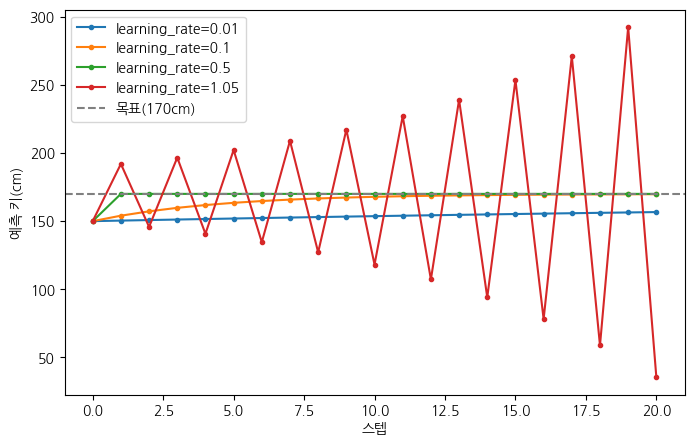

learning_rate=0.01: 최종 예측 = 156.65cm
learning_rate=0.1: 최종 예측 = 169.77cm
learning_rate=0.5: 최종 예측 = 170.00cm
learning_rate=1.05: 최종 예측 = 35.45cm


In [21]:
# 코드 입력

import matplotlib.pyplot as plt

# 학습률(보폭)을 4가지로 바꿔가며 같은 게임을 반복해봅니다
results = {}
for lr in [0.01, 0.1, 0.5, 1.05]:
    results[lr] = gradient_descent(learning_rate=lr)

plt.figure(figsize=(8, 5))

for lr, history in results.items():
    plt.plot(history, marker="o", markersize=3, label=f"learning_rate={lr}")
plt.axhline(y=170, color="gray", linestyle="--", label="목표(170cm)")

plt.xlabel("스텝")
plt.ylabel("예측 키(cm)")
plt.legend()
plt.show()

for lr, history in results.items():
    print(f"learning_rate={lr}: 최종 예측 = {history[-1]:.2f}cm")

> ⚠️ 학습률이 너무 작으면(0.01) 목표까지 하염없이 느리게 가고, 너무 크면(1.05) 목표를 지나쳐 **점점 더 멀리 튕겨 나갑니다(발산, divergence)**. 계단을 내려갈 때 보폭이 너무 크면 반대편 벽에 부딪히는 것과 같습니다. 실무에서 "학습률 튜닝"이 중요한 이유가 바로 이것입니다.

---

## 🧩 Check Point

**Q1.** 내적(dot product)은 한 문장으로 무엇을 하는 연산인가요?
<details><summary>정답</summary>짝이 맞는 숫자끼리 곱해서 전부 더하는 연산입니다. 선형 모델은 "특성 · 가중치" 내적으로 예측값을 계산합니다.</details>

**Q2.** 손실(loss)을 그냥 (예측 - 정답)이 아니라 제곱으로 정의하는 이유는 무엇인가요?
<details><summary>정답</summary>제곱하면 음수가 사라져 "모자람"과 "넘침"을 같은 크기의 벌점으로 다룰 수 있고, 크게 틀릴수록 벌점이 훨씬 커져 큰 오차부터 줄이도록 유도하기 때문입니다.</details>

**Q3.** 기울기(gradient)가 음수로 나왔다면, 예측값을 어떻게 해야 한다는 신호인가요?
<details><summary>정답</summary>예측이 정답보다 작다는 뜻이므로 예측값을 키워야 합니다. 경사하강법은 항상 "기울기의 반대 방향"(내리막길)으로 이동하므로, 음수 기울기 → 예측 증가가 됩니다.</details>

**Q4.** 학습률을 지나치게 크게 설정하면 어떤 문제가 생길 수 있나요?
<details><summary>정답</summary>목표값을 지나쳐 튕겨나가며 오히려 손실이 커지는 발산(divergence) 현상이 나타날 수 있습니다.</details>

---

## 💻 실습 (자습 시간)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# TODO 1 (내적 - 문구점 계산): 연필 5자루(자루당 500원), 공책 3권(권당 1200원), 지우개 2개(개당 300원)
#        오늘 총매출을 내적(np.dot)으로 계산하세요. 손 계산 결과와 같은지도 확인해보세요.
```

</details>

In [22]:
# TODO 1 (내적 - 문구점 계산)
# 연필 5자루(자루당 500원), 공책 3권(권당 1200원), 지우개 2개(개당 300원)
# 오늘 총매출을 내적(np.dot)으로 계산하세요. 손 계산 결과와 같은지도 확인해보세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import numpy as np
sold = np.array([5, 3, 2])            # [연필, 공책, 지우개] 판매 개수
price = np.array([500, 1200, 300])    # 각각의 가격
print("총매출:", np.dot(sold, price), "원")   # 5×500 + 3×1200 + 2×300 = 6700
```

</details>

In [23]:
# 코드 입력

import numpy as np

sold = np.array([5,3,2])
prices = np.array([500,1200,300])

print('손계산:', (5*500) + (3*1200) + (2*300))
print('내적으로 계산:', np.dot(sold, prices))


손계산: 6700
내적으로 계산: 6700


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# TODO 2 (내적 → 예측): 배달 라이더의 오늘 기록이 [35건, 100km]입니다.
#        가중치 [3000, 100]을 그대로 사용해 예상 수입을 내적으로 계산하세요.
```

</details>

In [24]:
# TODO 2 (내적 → 예측)
# 배달 라이더의 오늘 기록이 [35건, 100km]입니다.
# 가중치 [3000, 100]을 그대로 사용해 예상 수입을 내적으로 계산하세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
rider = np.array([35, 100])
weights = np.array([3000, 100])
print("예상 수입:", np.dot(rider, weights), "원")   # 35×3000 + 100×100 = 115000
```

</details>

In [25]:
# 코드 입력

rider = np.array([35,100])
weights = np.array([3000,100])
print('오늘 수입:', np.dot(rider, weights))


오늘 수입: 115000


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# TODO 3 (경사하강법): 상자의 실제 무게는 65kg인데, 첫 예측은 80kg이었습니다.
#        loss = (예측 - 65)² 에 대해 학습률 0.1로 20스텝 경사하강법을 돌려
#        예측이 65에 가까워지는지 확인하세요.
```

</details>

In [26]:
# TODO 3 (경사하강법)
# 상자의 실제 무게는 65kg인데, 첫 예측은 80kg이었습니다.
# loss = (예측 - 65)² 에 대해 학습률 0.1로 20스텝 경사하강법을 돌려
#  예측이 65에 가까워지는지 확인하세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
guess = 80
for _ in range(20):
    gradient = 2 * (guess - 65)       # 기울기가 양수 → "예측이 크다, 줄여라!"
    guess = guess - 0.1 * gradient
print("최종 예측:", round(guess, 2), "kg")
```

</details>

In [27]:
# 코드 입력

guess = 80

for _ in range(20):
    gradient = 2 * (guess - 65)
    guess = guess - 0.1 * gradient
print('최종 예측 무게:', guess, 'kg')


최종 예측 무게: 65.17293822569103 kg


---

## 📝 실습 과제 (자습 시간)

In [28]:
# 과제 1: loss(w) = (w-3)² 함수에 대해, 시작점(start)을 -10, 0, 10으로 각각 다르게 줘도
#         동일한 학습률(0.1)로 항상 w=3에 수렴하는지 확인하세요

# 과제 2: 학습률을 정확히 1.0으로 주면 어떤 일이 벌어질까요?
#         시작점 0에서 10스텝을 돌려 w값의 변화를 출력하고, 왜 그런 일이 생기는지 주석으로 설명해보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
def gd_3(learning_rate, steps=20, start=0):
    w = start
    for _ in range(steps):
        w = w - learning_rate * (2 * (w - 3))
    return w

for start in [-10, 0, 10]:
    print(f"start={start} -> 최종 w={gd_3(0.1, start=start):.2f}")
# 어디서 출발하든 같은 목표(3)에 도착합니다 — 밥그릇 모양 손실 함수의 특징입니다
```

</details>

In [65]:
# 과제 1 답안

def gd_3(learning_rate, steps=20, start=0):
    w = start
    for _ in range(steps):
        w = w - learning_rate * (2 * (w - 3))
    return w

for start in [-10,0,10]:
    print(f'start={start} -> 최종 w={gd_3(0.1, start=start):.2f}')


start=-10 -> 최종 w=2.85
start=0 -> 최종 w=2.97
start=10 -> 최종 w=3.08


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
w = 0
for step in range(10):
    w = w - 1.0 * (2 * (w - 3))
    print(f"{step+1}스텝: w = {w}")
# 이유: 새 w = w - 2(w-3) = 6 - w 가 되어, 목표(3)를 기준으로 정확히 반대편 같은 거리로
#       점프합니다. 그래서 0 → 6 → 0 → 6 ... 영원히 진동하며 절대 수렴하지 못합니다.
```

</details>

In [66]:
# 과제 2 답안

w = 0   # 초기 예측값
# 10번의 경사 하강법 스텝 반복
for step in range(10):
    # 1.0 : 학습률, 한 스텝에 w를 얼마나 크게 움직일지 결정
    w = w - 1.0 * (2 * (w - 3)) # (2 * (w - 3)) : 현재 w 위치에서 기울기
    print(f'{step+1}스텝: w = {w}')

# 학습률이 너무 크게 설정되어서 경사 하강법이 목표를 지나쳐 발산함

1스텝: w = 6.0
2스텝: w = 0.0
3스텝: w = 6.0
4스텝: w = 0.0
5스텝: w = 6.0
6스텝: w = 0.0
7스텝: w = 6.0
8스텝: w = 0.0
9스텝: w = 6.0
10스텝: w = 0.0


---

## 📌 핵심 정리

- 내적: 짝끼리 곱해서 전부 더하기 — 선형 모델의 예측값 = 특성 · 가중치
- 경사하강법: "틀린 만큼, 반대 방향으로, 조금씩" — loss의 기울기 반대 방향으로 이동하며 가중치를 고치는 과정
- 학습률: 한 걸음의 보폭 — 너무 작으면 느리고, 너무 크면 발산

# 📘 CH11-02. 문제 유형 판별 게임

━━━━━━━━━━━━━━━━

> 🗂️ **구성**: (개념은 프레젠테이션 참고) → Round 1: 미니 데이터로 회귀 vs 분류 눈으로 보기 → 시나리오 판별 게임(10문항) → Round 2: 실제 데이터로 확인 → Check Point
> ⏱️ **예상 소요시간**: 55분
> 🎚️ **난이도**: ★★★☆☆

---

## 🤔 오늘의 미션

> 실무에서 데이터 분석가가 가장 먼저 하는 일은 코드를 짜는 게 아니라 **"이건 어떤 유형의 문제인가?"** 를 판단하는 것입니다. 잘못 판단하면 애초에 잘못된 모델을 고르게 됩니다. 이번 시간에는 ① 직접 만든 초미니 데이터로 회귀와 분류의 차이를 **눈으로** 먼저 보고, ② 10가지 실무 시나리오로 판별 감각을 훈련한 뒤, ③ 실제 데이터에서 같은 판단을 한 번 더 연습합니다.

### Round 1: 눈으로 보는 회귀 vs 분류 — 아이스크림 가게 사장님의 두 가지 고민

> 🍦 **상황**: 아이스크림 가게 사장님에게 두 가지 고민이 있습니다.
>
> - 고민 ①: "내일 기온이 33도라는데, **몇 개나** 팔릴까?" → 맞혀야 하는 답이 **연속적인 숫자** → **회귀**
> - 고민 ②: "저 손님, 다음 달에 **또 올까 안 올까**?" → 맞혀야 하는 답이 **정해진 카테고리(온다/안 온다)** → **분류**
>
> 같은 가게, 같은 손님 데이터라도 **어떤 질문을 던지느냐**에 따라 문제 유형이 달라집니다. 직접 만든 초미니 데이터로 두 문제의 생김새를 비교해봅시다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import matplotlib.pyplot as plt

# 🍦 [회귀 문제] 지난 8일간의 기록: 그날의 기온과 판매량 (직접 만든 초미니 데이터)
temps = [20, 22, 24, 26, 28, 30, 32, 34]        # 그날의 최고기온(℃)
sales = [42, 47, 55, 62, 71, 83, 94, 108]       # 그날 팔린 개수 → 연속적인 숫자!

plt.figure(figsize=(6, 4))
plt.scatter(temps, sales)
plt.xlabel("기온(℃)")
plt.ylabel("판매량(개)")
plt.title("회귀: '몇 개?'라는 숫자를 예측")
plt.show()

print("기온이 오를수록 판매량도 오르는 '경향'이 보이나요?")
print("회귀 모델이 하는 일 = 이 경향을 선으로 학습해서, 새 기온에 대한 숫자를 찍어주는 것")
```

</details>

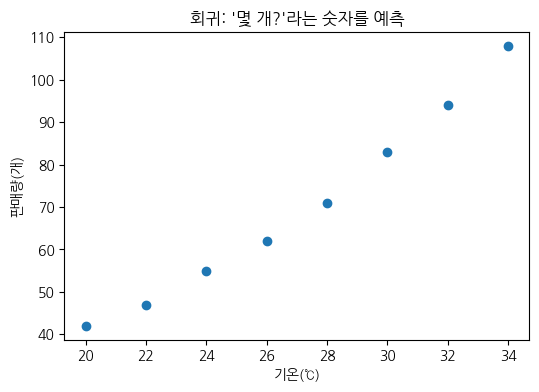

기온이 오를수록 판매량도 오르는 '경향'이 보이나요?
회귀 모델이 하는 일 = 이 경향을 선으로 학습해서, 새 기온에 대한 숫자를 찍어주는 것


In [31]:
# 코드 입력

import matplotlib.pyplot as plt

# 🍦 [회귀 문제] 지난 8일간의 기록: 그날의 기온과 판매량 (직접 만든 초미니 데이터)
temps = [20, 22, 24, 26, 28, 30, 32, 34]        # 그날의 최고기온(℃)
sales = [42, 47, 55, 62, 71, 83, 94, 108]       # 그날 팔린 개수 → 연속적인 숫자!

plt.figure(figsize=(6, 4))
plt.scatter(temps, sales)

plt.xlabel("기온(℃)")
plt.ylabel("판매량(개)")
plt.title("회귀: '몇 개?'라는 숫자를 예측")
plt.show()

print("기온이 오를수록 판매량도 오르는 '경향'이 보이나요?")
print("회귀 모델이 하는 일 = 이 경향을 선으로 학습해서, 새 기온에 대한 숫자를 찍어주는 것")

> 🔮 **예측해보세요**: 이 경향이 이어진다면 기온 36도인 날의 판매량은 대략 몇 개쯤일까요? 여러분이 방금 머릿속으로 한 그 추정이 바로 회귀 모델이 하는 일입니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 🙋 [분류 문제] 손님 10명의 기록: 지난달 방문 횟수와 재방문 여부
visits  = [1, 1, 2, 2, 3, 4, 5, 6, 7, 8]        # 지난달 방문 횟수
revisit = [0, 0, 0, 1, 0, 1, 1, 1, 1, 1]        # 다음 달 재방문 여부 → 0/1 카테고리!

plt.figure(figsize=(6, 3))
plt.scatter(visits, revisit, c=revisit, cmap="coolwarm", s=80)
plt.yticks([0, 1], ["안 옴 (0)", "또 옴 (1)"])
plt.xlabel("지난달 방문 횟수")
plt.title("분류: '온다 / 안 온다' 중 하나를 예측")
plt.show()

print("분류의 답은 연속적인 숫자가 아니라 '둘 중 하나'입니다.")
print("대략 몇 회 이상 방문한 손님부터 재방문 그룹으로 보이나요? 그 경계를 찾는 게 분류 모델의 일입니다.")
```

</details>

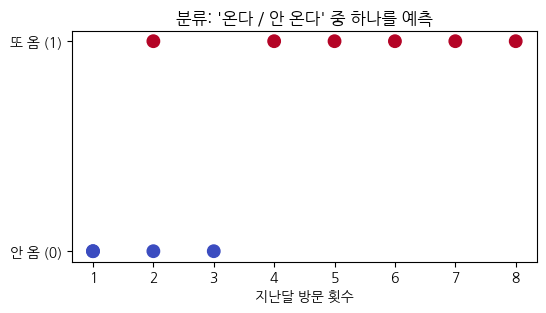

분류의 답은 연속적인 숫자가 아니라 '둘 중 하나'입니다.
대략 몇 회 이상 방문한 손님부터 재방문 그룹으로 보이나요? 그 경계를 찾는 게 분류 모델의 일입니다.


In [32]:
# 🙋 [분류 문제] 손님 10명의 기록: 지난달 방문 횟수와 재방문 여부

visits  = [1, 1, 2, 2, 3, 4, 5, 6, 7, 8]        # 지난달 방문 횟수
revisit = [0, 0, 0, 1, 0, 1, 1, 1, 1, 1]        # 다음 달 재방문 여부 → 0/1 카테고리!

plt.figure(figsize=(6, 3))
plt.scatter(visits, revisit, c=revisit, cmap="coolwarm", s=80)
plt.yticks([0, 1], ["안 옴 (0)", "또 옴 (1)"])
plt.xlabel("지난달 방문 횟수")
plt.title("분류: '온다 / 안 온다' 중 하나를 예측")
plt.show()

print("분류의 답은 연속적인 숫자가 아니라 '둘 중 하나'입니다.")
print("대략 몇 회 이상 방문한 손님부터 재방문 그룹으로 보이나요? 그 경계를 찾는 게 분류 모델의 일입니다.")

> 💡 두 그래프의 세로축을 비교해보세요. 회귀는 세로축이 **끝없이 이어지는 숫자**(42, 47, 55...), 분류는 **정해진 칸**(0 아니면 1)입니다. 판단 기준은 언제나 하나 — **"최종적으로 맞혀야 하는 답이 연속적인 숫자인가, 정해진 카테고리인가?"**

### 시나리오 판별 게임 — 하나씩 판단해보고 펼쳐서 확인하세요

**시나리오 1.** 다음 달 매장 매출이 얼마일지 예측한다.
<details><summary>정답</summary>회귀 — 예측 대상이 연속적인 숫자(매출 금액)입니다.</details>

**시나리오 2.** 이메일이 스팸인지 아닌지 판단한다.
<details><summary>정답</summary>분류 — 정해진 두 카테고리(스팸/정상) 중 하나를 맞히는 문제입니다.</details>

**시나리오 3.** 고객 10만 명을 구매 패턴이 비슷한 그룹끼리 자동으로 묶는다 (그룹 이름표는 없음).
<details><summary>정답</summary>비지도학습 — 정답 라벨 없이 데이터의 패턴만으로 그룹을 나눕니다 (군집화).</details>

**시나리오 4.** 게임 캐릭터가 시행착오를 거듭하며 점수를 최대화하는 플레이 방식을 스스로 익힌다.
<details><summary>정답</summary>강화학습 — 보상(점수)을 통해 행동을 시행착오로 학습합니다.</details>

**시나리오 5.** 대출 신청자가 상환할지 연체할지 예측한다.
<details><summary>정답</summary>분류 — 상환/연체라는 두 카테고리를 맞히는 문제입니다.</details>

**시나리오 6.** 집의 평수, 층수, 위치로 전세 보증금을 예측한다.
<details><summary>정답</summary>회귀 — 보증금이라는 연속적인 숫자를 예측합니다.</details>

**시나리오 7.** 수십만 건의 신용카드 거래 중, 라벨(사기 여부) 없이 "평소와 다른 이상한 패턴"을 찾아낸다.
<details><summary>정답</summary>비지도학습 — 정답 라벨이 없는 상태에서 이상치를 탐지하는 문제입니다 (이상 탐지도 비지도학습의 대표 사례).</details>

**시나리오 8.** 자율주행차가 다양한 도로 상황에서 시행착오를 거치며 운전 정책을 개선한다.
<details><summary>정답</summary>강화학습 — 주행 결과(보상/사고)를 통해 정책을 점진적으로 개선합니다.</details>

**시나리오 9.** 사진 속 동물이 고양이/개/토끼 중 무엇인지 분류한다.
<details><summary>정답</summary>분류 — 정해진 세 카테고리 중 하나를 맞히는 다중 분류 문제입니다.</details>

**시나리오 10. (헷갈리는 문제)** 고객의 나이, 소득, 구매 이력으로 "이 고객이 프리미엄 회원으로 전환할 확률"을 0~100%로 예측한다.
<details><summary>정답</summary>분류(확률 예측) — 겉보기엔 숫자를 예측하는 것 같지만, "전환 여부(Yes/No)"라는 카테고리를 확률로 표현하는 것이므로 회귀가 아니라 분류입니다. 실무에서 이 부분을 헷갈리는 경우가 매우 많습니다.</details>

> 💡 시나리오 10처럼 "확률"이라는 단어 때문에 회귀로 착각하기 쉬운 문제가 실무에서 자주 등장합니다. 핵심 질문은 하나입니다 — **"최종적으로 맞혀야 하는 답이 연속적인 숫자인가, 정해진 카테고리인가?"**

### Round 2: 실제 데이터로 확인하기 — 회귀 / 분류 / 비지도학습

> 이제 방금 세운 판단 기준을 **진짜 데이터**에 적용해봅니다. sklearn에는 연습용 데이터가 내장되어 있어 다운로드나 API 키 없이 바로 쓸 수 있습니다. 목표값(target)의 생김새만 봐도 회귀인지 분류인지 구분할 수 있는지 확인해보세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.datasets import load_iris, fetch_california_housing

# [분류] 붓꽃(iris) 데이터: 꽃잎·꽃받침의 크기로 품종(3종 중 하나)을 맞히는 문제
iris = load_iris(as_frame=True)
print("[분류] 목표값 예시:", iris.target[:5].tolist())
print("       0/1/2는 크기가 아니라 품종 '이름표'입니다:", list(iris.target_names))

# [회귀] 캘리포니아 주택 데이터: 동네 정보(소득, 방 개수 등)로 집값을 맞히는 문제
housing = fetch_california_housing(as_frame=True)
print("[회귀] 목표값 예시:", housing.target[:5].round(2).tolist(), "(단위: 10만 달러)")
print("       4.53, 3.59, 3.52 ... 처럼 딱 떨어지지 않는 '연속적인 숫자'입니다")
```

</details>

In [33]:
# 코드 입력

from sklearn.datasets import load_iris, fetch_california_housing

# [분류] 붓꽃(iris) 데이터: 꽃잎·꽃받침의 크기로 품종(3종 중 하나)을 맞히는 문제

iris = load_iris(as_frame=True)
print(iris.target)

print("==================================================")
# [회귀] 캘리포니아 주택 데이터: 동네 정보(소득, 방 개수 등)로 집값을 맞히는 문제
housing = fetch_california_housing(as_frame=True)
print(housing.target)



0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64
0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64


> 🔮 **예측해보세요**: 만약 어떤 데이터의 목표값이 `[1, 0, 2, 1, 1, ...]`처럼 몇 가지 정수만 반복된다면, 그리고 `[3.72, 1.05, 2.48, ...]`처럼 제각각의 소수라면 — 각각 어떤 문제 유형일 가능성이 높을까요?

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# [비지도학습] 품종 이름표를 "모른다고 가정"하고, 특성만으로 비슷한 꽃끼리 묶어보기
from sklearn.cluster import KMeans

X_unlabeled = iris.data                        # target(정답)은 일부러 사용하지 않습니다!
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_unlabeled)     # "알아서 3그룹으로 나눠줘"

print("데이터가 스스로 나뉜 그룹:", clusters[:10])
print("실제 품종(정답, 참고용):  ", iris.target[:10].tolist())
```

</details>

In [34]:
# [비지도학습] 품종 이름표를 "모른다고 가정"하고, 특성만으로 비슷한 꽃끼리 묶어보기

from sklearn.cluster import KMeans

X_unlabeled = iris.data  # target(정답)은 일부러 사용하지 않습니다!
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_unlabeled)     # "알아서 3그룹으로 나눠줘"

# 잘 분류함
print("데이터가 스스로 나뉜 그룹:", clusters[:10])
print("실제 품종(정답, 참고용):  ", iris.target[:10].tolist())

데이터가 스스로 나뉜 그룹: [1 1 1 1 1 1 1 1 1 1]
실제 품종(정답, 참고용):   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


> 🔮 **예측해보세요**: 결과를 확인하기 전에 — 정답 라벨(품종)을 전혀 안 보여줬는데도 KMeans가 만든 그룹이 실제 품종과 얼마나 비슷하게 나뉠지 예상해보세요.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 그룹이 잘 나뉘었는지 눈으로 확인 (4개 특성 중 꽃잎 길이/폭 2개만 사용해 그림)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(iris.data["petal length (cm)"], iris.data["petal width (cm)"],
            c=clusters, cmap="viridis")
plt.xlabel("꽃잎 길이(cm)")
plt.ylabel("꽃잎 폭(cm)")
plt.title("비지도학습: 정답 없이도 데이터가 스스로 3그룹으로")
plt.show()

print("이름표 하나 없이도 비슷한 꽃끼리 색이 묶였습니다 — 이것이 비지도학습(군집화)입니다.")
```

</details>

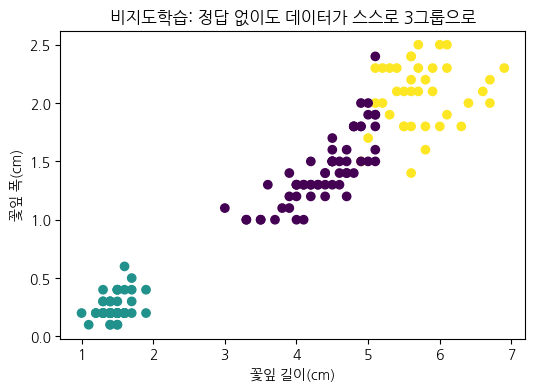

이름표 하나 없이도 비슷한 꽃끼리 색이 묶였습니다 — 이것이 비지도학습(군집화)입니다.


In [35]:
# 그룹이 잘 나뉘었는지 눈으로 확인
# (4개 특성 중 꽃잎 길이/폭 2개만 사용해 그림)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(iris.data["petal length (cm)"], iris.data["petal width (cm)"],
            c=clusters, cmap="viridis")
plt.xlabel("꽃잎 길이(cm)")
plt.ylabel("꽃잎 폭(cm)")
plt.title("비지도학습: 정답 없이도 데이터가 스스로 3그룹으로")
plt.show()

print("이름표 하나 없이도 비슷한 꽃끼리 색이 묶였습니다 — 이것이 비지도학습(군집화)입니다.")

---

## 🧩 Check Point

**Q1.** "이 고객이 이탈할 확률 82%"처럼 확률을 예측하는 문제는 회귀일까요, 분류일까요?
<details><summary>정답</summary>분류입니다. 최종적으로 맞히려는 것은 "이탈/잔류"라는 카테고리이고, 확률은 그 카테고리에 대한 신뢰도를 표현한 것일 뿐입니다.</details>

**Q2.** 정답 라벨이 아예 없는 데이터에서 패턴을 찾아 그룹을 나누는 학습 방식은?
<details><summary>정답</summary>비지도학습</details>

**Q3.** 어떤 데이터의 목표값(target)을 출력해보니 `[2, 0, 1, 1, 2, 0, ...]`처럼 세 가지 정수만 반복됩니다. 어떤 문제 유형일 가능성이 높을까요?
<details><summary>정답</summary>분류(3개 클래스)입니다. 목표값이 소수점 있는 제각각의 연속값이라면 회귀일 가능성이 높습니다.</details>

**Q4.** 신용카드 이상거래 탐지처럼 "평소와 다른 패턴"을 찾는 문제가 비지도학습으로 분류되는 이유는 무엇인가요?
<details><summary>정답</summary>"이것이 사기다"라는 정답 라벨 없이, 데이터의 일반적인 패턴에서 벗어난 것을 찾아내는 방식이기 때문입니다.</details>

---

## 💻 실습 (자습 시간)

In [36]:
# TODO 1 (데이터 로드 + 판별)
# sklearn의 load_wine()으로 데이터를 불러와
# target의 앞 10개를 출력하고, 이 문제가 회귀인지 분류인지 주석으로 판단해보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
print(wine.data.head())
print(wine.target[:10].tolist())
# 판단: 목표값이 0/1/2 세 가지 정수(와인 품종 이름표)만 반복 → 분류 문제
```

</details>

In [74]:
# 코드 입력

from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)

display(wine.data.head())
print("================================================================")
print(wine.target[:10].tolist())

# 이 문제가 회귀인지 분류인지 판단해보세요 -> 분류
print("각 품종(target)의 개수:")
display(wine.target.value_counts().sort_index())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
각 품종(target)의 개수:


,count
target,
0,59
1,71
2,48


In [38]:
# TODO 2 (나만의 미니 회귀 데이터)
# 공부시간(hours)과 시험점수(scores) 리스트를
# 각각 6개씩 직접 만들어 산점도를 그리고, 이것이 회귀 문제인 이유를 주석으로 적어보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
import matplotlib.pyplot as plt
hours  = [1, 2, 3, 5, 7, 9]
scores = [45, 52, 60, 72, 85, 93]
plt.scatter(hours, scores)
plt.xlabel("공부시간")
plt.ylabel("시험점수")
plt.show()
# 이유: 맞혀야 하는 답(시험점수)이 정해진 카테고리가 아니라 연속적인 숫자이기 때문
```

</details>

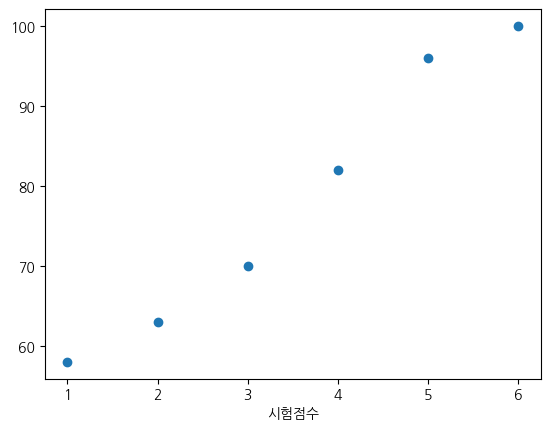

In [75]:
# 코드 입력

hours = [1,2,3,4,5,6]
scores = [58,63,70,82,96,100]

import matplotlib.pyplot as plt
plt.scatter(hours, scores)
plt.xlabel('공부시간')
plt.xlabel('시험점수')
plt.show()

# 회귀인 이유: 예측하고자 하는 시험점수가 정해진 카테고리가 아니라 연속적인 숫자 값을 가지기 때문.
# 공부 시간에 따라 시험 점수가 몇 점이 나올지를 예측하는 것이 목표


In [40]:
# TODO 3 (판별 연습)
# 아래 세 가지 문제가 회귀/분류/비지도학습 중 무엇인지 주석으로 답을 적어보세요

# ① 다음 분기 광고비 대비 매출 예측
# ② 리뷰 텍스트가 1~5점 중 몇 점짜리 감성인지 분류
# ③ 수천 개 상품을 특징이 비슷한 카테고리로 자동 그룹화

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
# ① 회귀 (연속적인 매출 숫자)
# ② 분류 (1~5점이라는 정해진 카테고리)
# ③ 비지도학습 (정답 라벨 없이 그룹화)
print("판별 완료")
```

</details>

In [41]:
# 코드 입력

# 회귀 (연속적인 매출 숫자 값)
# 분류 (1~5점 분류)
# 비지도학습 (정답 라벨 없이 그룹화)


---

## 📝 실습 과제 (자습 시간)

In [42]:
# 과제: 여러분이 겪었거나 들어본 실제 업무/일상 상황을 3개 떠올려,
# 각각 회귀/분류/비지도학습/강화학습 중 무엇에 해당하는지와 그 이유를 적어보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
my_scenarios = [
    ("다음 주 예상 배송 물량", "회귀 - 연속적인 숫자(물량)를 예측"),
    ("고객 문의를 담당 부서로 자동 배정", "분류 - 정해진 부서 카테고리 중 하나로 배정"),
    ("사내 문서를 주제별로 자동 정리", "비지도학습 - 정답 라벨 없이 유사한 문서끼리 그룹화"),
]
for scenario, reason in my_scenarios:
    print(f"{scenario} -> {reason}")
```

</details>

In [43]:
# 코드 입력
# 주석으로 자유롭게 작성 (코드 활용 X)
# 1. 날씨 앱 - 내일 최고 기온 예측
# 회귀, 예측하려는 값이 내일 최고 기온이라는 연속적인 숫자이기 때문

# 2. 은행 앱 - 사기 계좌 탐지 시스템
# 분류, 정상 거래/사기 거래 두 가지 카테고리 중 하나로 판단하기 때문

# 3. 음악 스트리밍 서비스 - 개인별 음악 추천
# 비지도학습, 사용자가 어떤 노래를 좋아하고 싫어하는지, 어떤 노래들을 함께 듣는지 등의 데이터 수집
# 각 노래에 대해 신나는 댄스곡, 잔잔한 발라드 등과 같은 명확한 라벨 없이 데이터를 통해
# 유사한 노래들을 그룹으로 묶거나 비슷한 취향을 가진 사용자들을 찾아서 개인에게 맞는 노래를 추천해줌

# ! 미리 정해진 정답 라벨 없이 데이터 내의 숨겨진 패턴과 유사성을 찾아내어
# 새로운 정보를 생성하는 것이 비지도 학습의 특징


---

## 📌 핵심 정리

- 판단 기준은 하나: 최종적으로 맞혀야 하는 답이 연속적인 숫자(회귀)인가, 정해진 카테고리(분류)인가
- 회귀 = "숫자를 찍는" 문제, 분류 = "칸을 고르는" 문제 — 목표값의 생김새만 봐도 구분 가능
- 정답 라벨이 없으면 비지도학습, 시행착오와 보상이 있으면 강화학습
- "확률"이라는 단어에 속아 회귀로 착각하지 않도록 주의

# 📘 CH10-03. 데이터 분할 — 상황별 의사결정 + 첫 모델 만들기

━━━━━━━━━━━━━━━━

> 🗂️ **구성**: (개념은 프레젠테이션 참고) → Round 1: "왜 나누는가" 족보 유출 실험 → Round 2: 분할 전략 판단 4문항(각각 다른 데이터로 실행) → 미니 캡스톤(첫 모델 완성 + 새 데이터 예측) → Check Point
> ⏱️ **예상 소요시간**: 65분
> 🎚️ **난이도**: ★★★★☆

---

## 🤔 오늘의 미션

> 데이터 분할은 `train_test_split()` 한 줄이 전부가 아닙니다. **왜 나누는지**를 몸으로 느끼고, **어떤 상황에 어떤 분할 방식을 써야 하는지 판단하는 것**이 진짜 실력입니다. 먼저 "안 나누면 무슨 일이 생기는지"를 실험으로 직접 확인한 뒤, 4가지 상황을 각기 다른 데이터로 판단해보고, 마지막에는 오늘 배운 전부를 합쳐 첫 머신러닝 모델을 완성합니다.

### Round 1: 왜 나누는가? — 족보 유출 실험

> 📝 **상황**: 시험공부를 '기출 문제집'으로 했는데, 시험에 그 문제집의 문제가 **번호까지 그대로** 나온다면? 누구나 100점을 받겠지만, 그게 실력일까요?
>
> 머신러닝도 똑같습니다. **공부한 데이터(훈련 데이터)로 시험(평가)까지 보면 점수가 부풀려집니다.** 그래서 데이터를 처음부터 둘로 나눠 둡니다 — 문제집(훈련용)과, 모델에게 절대 미리 보여주지 않는 진짜 시험지(테스트용)로. 정말 점수가 부풀려지는지 직접 실험해봅시다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

# 데이터를 문제집(훈련 80%)과 진짜 시험지(테스트 20%)로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 일부러 "문제를 통째로 외우는" 모델을 만들어 봅니다
# (n_neighbors=1: 가장 가까운 데이터 딱 1개만 보고 그대로 따라 답하는 방식)
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)                    # 문제집으로 공부(학습)

print(f"공부한 문제로 본 시험(훈련 데이터) 점수: {model.score(X_train, y_train)*100:.1f}점")
print(f"처음 보는 문제로 본 시험(테스트 데이터) 점수: {model.score(X_test, y_test)*100:.1f}점")
```

</details>

In [44]:
# 코드 입력
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris(as_frame=True)
X,y = iris.data, iris.target

# 데이터를 문제집(훈련 80%)과 진짜 시험지(테스트 20%)로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(120, 4) (30, 4)
(120,) (30,)


In [45]:
# 일부러 "문제를 통째로 외우는" 모델을 만들어 봅니다
# (n_neighbors=1: 가장 가까운 데이터 딱 1개만 보고 그대로 따라 답하는 방식)
# 즉 문제를 통재로 외움

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)

print(f"공부한 문제로 본 시험(훈련 데이터) 점수: {model.score(X_train, y_train)*100:.1f}점")
print(f"처음 보는 문제로 본 시험(테스트 데이터) 점수: {model.score(X_test, y_test)*100:.1f}점")

공부한 문제로 본 시험(훈련 데이터) 점수: 100.0점
처음 보는 문제로 본 시험(테스트 데이터) 점수: 100.0점


> 🔮 **예측해보세요**: 실행 전에 — 두 점수 중 어느 쪽이 높을까요? 특히 "공부한 문제 그대로" 본 시험 점수는 정확히 몇 점이 나올까요?

> 💡 훈련 데이터 점수 100점은 실력이 아니라 **암기**입니다. 모델의 진짜 실력은 **한 번도 본 적 없는 데이터**에 대한 점수로만 알 수 있습니다. 이것이 데이터를 나누는 유일하고도 충분한 이유입니다.

### Round 2: 상황별 분할 전략 판단 — 4가지 상황, 4가지 데이터

이제 "나눈다"는 전제 위에서, **상황에 따라 나누는 방법이 달라진다**는 것을 판단 연습으로 익힙니다. (같은 데이터로 문법만 반복하지 않습니다!)

### 상황 1. 붓꽃 품종 분류 — 품종별 개수가 균등하지 않다면?

> 🔮 **먼저 판단해보세요**: 무작위로 나누기 vs 품종 비율을 유지하며 나누기, 어느 쪽이 안전할까요?
<details><summary>정답</summary>품종 비율을 유지하며 나누기(stratify)입니다. 무작위로만 나누면 우연히 테스트셋에 특정 품종이 거의 없을 수도 있습니다.</details>

### stratify
- 개념: 데이터를 훈련용과 테스트용으로 나눌 때, 정답(클래스)의 비율을 원래 비율 그대로 유지하며 쪼개주는 옵션입니다.

- 필요성: 무작위로 나눌 때 특정 정답 종류가 한쪽에만 쏠려 모델 학습이나 평가가 왜곡되는 현상을 막아줍니다.

- 사용법: train_test_split(..., stratify=y)와 같이 정답 라벨 변수(y)를 입력하여 적용합니다.

- 핵심 효과: 훈련지와 시험지 모두에 모든 클래스가 균등한 비율로 포함되어, 모델 평가의 신뢰도와 안정성이 높아집니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# stratify=y를 지정하면, 나눈 후에도 원본과 똑같은 클래스 비율을 유지합니다
# (반 학생을 두 조로 나눌 때, 남녀 비율을 양쪽 모두 똑같이 맞추는 것과 같은 원리)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("훈련 데이터 품종 비율:\n", y_train.value_counts(normalize=True).round(2))
print("테스트 데이터 품종 비율:\n", y_test.value_counts(normalize=True).round(2))
```

</details>

In [46]:
# stratify=y를 지정하면, 나눈 후에도 원본과 똑같은 클래스 비율을 유지합니다
# (반 학생을 두 조로 나눌 때, 남녀 비율을 양쪽 모두 똑같이 맞추는 것과 같은 원리)
# 정답 정보는 y에만 있으니, y만 확인

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# normalize = True 옵션: 개수가 아닌 비율%로 바꿔서 보여줘.
print("훈련 데이터 품종 비율:\n", y_train.value_counts(normalize=True).round(2))
print("테스트 데이터 품종 비율:\n", y_test.value_counts(normalize=True).round(2))

훈련 데이터 품종 비율:
 target
0    0.33
2    0.33
1    0.33
Name: proportion, dtype: float64
테스트 데이터 품종 비율:
 target
0    0.33
2    0.33
1    0.33
Name: proportion, dtype: float64


### 상황 2. 캘리포니아 주택 가격 예측 — 연속적인 숫자를 예측할 때는?

> 🔮 **먼저 판단해보세요**: 회귀 문제에도 stratify가 필요할까요?
<details><summary>정답</summary>일반적으로는 필요 없습니다. stratify는 "클래스 비율"을 맞추는 것인데, 회귀는 애초에 정해진 클래스가 없는 연속값이기 때문입니다. 무작위 분할이면 충분합니다.</details>

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.datasets import fetch_california_housing

# 회귀 문제: 목표값(집값)이 연속적인 숫자라 클래스 비율이라는 개념 자체가 없음
housing = fetch_california_housing(as_frame=True)
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    housing.data, housing.target, test_size=0.3, random_state=42
)
print(X_train_h.shape, X_test_h.shape)
```

</details>

In [47]:
# 코드 입력

from sklearn.datasets import fetch_california_housing

# 회귀 문제: 목표값(집값)이 연속적인 숫자라 클래스 비율이라는 개념 자체가 없음
# as_frame=True : 판다스 데이터프레임으로 가지고오기
housing = fetch_california_housing(as_frame=True)

# 분할하기
# stratify 옵션 넣으면 이미 에러가 남 (stratify=housing.target)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(housing.data, housing.target, test_size=0.3, random_state=42)
print(X_train_h.shape, X_test_h.shape)


(14448, 8) (6192, 8)


In [48]:
# print(housing)

display(housing.data.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [49]:
housing.target.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


### 상황 3. 카페의 다음 달 매출 예측 — 데이터가 시간 순서를 가지고 있다면?

> ☕ **상황**: 우리 카페의 지난 24개월치 월매출로 다음 달 매출을 예측하려 합니다.
> 🔮 **먼저 판단해보세요**: 월별 매출 데이터를 무작위로 섞어서 나눠도 괜찮을까요?
<details><summary>정답</summary>안 됩니다! 시계열 데이터를 무작위로 섞으면 "미래 데이터로 과거를 예측"하는 것과 같은 왜곡(데이터 누수)이 생깁니다. 시간 순서를 유지한 채 앞부분을 훈련, 뒷부분을 테스트로 나눠야 합니다.</details>

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import numpy as np
import pandas as pd

# ☕ 우리 카페의 24개월치 월별 매출 (시간 순서가 의미 있는 "시계열" 데이터)
monthly_sales = pd.Series(np.random.randint(800, 1200, size=24),
                           index=pd.date_range("2024-01", periods=24, freq="ME"))

# 방법 A: 일반적인 랜덤 분할 (❌ 시계열에는 부적합 — 미래가 훈련에, 과거가 시험에 섞임)
wrong_train, wrong_test = train_test_split(monthly_sales, test_size=0.2, random_state=42)

# 방법 B: 시간 순서를 유지한 채 앞 80%는 훈련, 뒤 20%는 테스트로 (⭕ 올바른 방법)
split_point = int(len(monthly_sales) * 0.8)
correct_train = monthly_sales[:split_point]
correct_test = monthly_sales[split_point:]

print("[잘못된 방법] 테스트 데이터 시점:", sorted(wrong_test.index)[:3], "...")
print("[올바른 방법] 테스트 데이터 시점:", correct_test.index[:3].tolist(), "...")
```

</details>

In [50]:
# 코드 입력

import numpy as np
import pandas as pd

# ☕ 우리 카페의 24개월치 월별 매출 (시간 순서가 의미 있는 "시계열" 데이터)
monthly_sales = pd.Series(np.random.randint(800, 1200, size=24),
                           index=pd.date_range("2024-01", periods=24, freq="ME"))

# 방법 A: 일반적인 랜덤 분할 (❌ 시계열에는 부적합 — 미래가 훈련에, 과거가 시험에 섞임)
wrong_train, wrong_test = train_test_split(monthly_sales, test_size=0.2, random_state=42)

# 방법 B: 시간 순서를 유지한 채 앞 80%는 훈련, 뒤 20%는 테스트로 (⭕ 올바른 방법)
split_point = int(len(monthly_sales) * 0.8)
correct_train = monthly_sales[:split_point]
correct_test = monthly_sales[split_point:]

print("[잘못된 방법] 테스트 데이터 시점:", sorted(wrong_test.index)[:3], "...")
print("[올바른 방법] 테스트 데이터 시점:", correct_test.index[:3].tolist(), "...")

[잘못된 방법] 테스트 데이터 시점: [Timestamp('2024-01-31 00:00:00'), Timestamp('2024-09-30 00:00:00'), Timestamp('2024-12-31 00:00:00')] ...
[올바른 방법] 테스트 데이터 시점: [Timestamp('2025-08-31 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-10-31 00:00:00')] ...


### 상황 4. 하이퍼파라미터도 튜닝해야 하는 프로젝트라면?

> 🔮 **먼저 판단해보세요**: 훈련/테스트 2분할로 충분할까요, 아니면 검증 데이터가 하나 더 필요할까요?
<details><summary>정답</summary>검증(validation) 데이터가 따로 필요합니다. 테스트 데이터로 여러 번 튜닝하며 결과를 확인하면, 테스트 데이터에 은근히 "맞춰가는" 문제가 생기기 때문입니다. 훈련/검증/테스트 3분할이 더 엄격한 평가 방법입니다. (비유: 모의고사=검증, 수능=테스트 — 수능 문제로 공부하면 안 되겠죠!)</details>

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 전체를 훈련(80%) + 검증(10%) + 테스트(10%)로 나누기 위해, 2단계로 분할합니다
# 1단계: 테스트 10%를 먼저 떼어놓고 → 2단계: 남은 90%를 훈련 80% / 검증 10%로
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42, stratify=y_temp)

print(f"훈련: {len(X_train)}개 / 검증: {len(X_val)}개 / 테스트: {len(X_test)}개")
```

</details>

In [51]:
# 전체를 훈련(80%) + 검증(10%) + 테스트(10%)로 나누기 위해, 2단계로 분할합니다
# 1단계: 테스트 10%를 먼저 떼어놓고 → 2단계: 남은 90%를 훈련 80% / 검증 10%로

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42, stratify=y_temp)

print(f"훈련: {len(X_train)}개 / 검증: {len(X_val)}개 / 테스트: {len(X_test)}개")

훈련: 120개 / 검증: 15개 / 테스트: 15개


> 🚀 **실무에서는?** "이 프로젝트는 클래스가 불균형한가?", "시간 순서가 의미 있는 데이터인가?", "하이퍼파라미터를 튜닝할 계획인가?" — 이 세 가지 질문에 대한 답이 분할 전략을 결정합니다. 무조건 `train_test_split(test_size=0.2)`만 쓰는 것이 아니라, 상황에 맞춰 판단하는 것이 핵심입니다.

---

## 🧩 Check Point

**Q1.** 훈련 데이터로 학습한 모델을 훈련 데이터로 평가하면 안 되는 이유는 무엇인가요?
<details><summary>정답</summary>공부한 문제로 시험을 보는 것과 같아 점수가 부풀려지기 때문입니다. 모델의 진짜 실력은 한 번도 본 적 없는(테스트) 데이터에 대한 점수로만 확인할 수 있습니다.</details>

**Q2.** 클래스 비율이 불균형한 분류 문제에서 훈련/테스트 데이터의 클래스 비율을 유지하려면 어떤 옵션을 사용해야 하나요?
<details><summary>정답</summary>stratify</details>

**Q3.** 월별 매출처럼 시간 순서가 있는 데이터를 무작위로 섞어서 분할하면 안 되는 이유는?
<details><summary>정답</summary>미래 데이터로 과거를 예측하는 것과 같은 왜곡(데이터 누수)이 발생해, 실제 배포 환경에서는 절대 불가능한 방식으로 성능이 부풀려질 수 있기 때문입니다.</details>

**Q4.** 훈련/검증/테스트 3분할에서 "검증" 데이터의 역할은 무엇인가요?
<details><summary>정답</summary>하이퍼파라미터를 튜닝하며 여러 번 성능을 확인하는 용도로 사용하고, 테스트 데이터는 최종 평가 전까지 한 번도 보지 않고 아껴둡니다.</details>

---

## 🎯 미니 캡스톤 — 오늘 배운 걸 모두 합쳐 첫 모델 완성하기

> 오늘 배운 순서 그대로 갑니다: **① 문제 유형 판단 → ② 분할 전략 선택 → ③ 모델 학습 → ④ 성능 확인 → ⑤ 새 데이터 예측.** 아직 모델 종류를 깊게 비교하진 않습니다 — 그건 내일(CH12)의 몫입니다. 오늘은 가장 단순한 모델 하나로 "내 손으로 처음부터 끝까지 완성했다"는 경험이 목표입니다.

### ① 문제 유형 판단

- 붓꽃의 꽃잎·꽃받침 길이로 품종을 맞히는 문제 → 정해진 카테고리(3개 품종) 중 하나를 맞히므로 **분류** 문제

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# ② 분할 전략 선택: 품종 비율이 치우칠 위험을 막기 위해 stratify 사용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"훈련: {len(X_train)}개 / 테스트: {len(X_test)}개")
```

</details>

In [52]:
# ② 분할 전략 선택: 품종 비율이 치우칠 위험을 막기 위해 stratify 사용

iris=load_iris(as_frame=True)
x = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"훈련: {len(X_train)}개 / 테스트: {len(X_test)}개")

훈련: 120개 / 테스트: 30개


### ③ 모델 학습 — 가장 단순한 분류 모델, KNN

- KNN(K-Nearest Neighbors): "나와 가장 가까운 이웃 K명이 어느 품종인지 보고 다수결로 정하는" 가장 직관적인 분류 방식

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)   # 가장 가까운 이웃 3명의 다수결
model.fit(X_train, y_train)                   # 학습: 훈련 데이터를 기억시키기

predictions = model.predict(X_test)           # 예측: 처음 보는 테스트 데이터에 답하기
print("예측 결과:", predictions[:10])
print("실제 정답:", y_test[:10].tolist())
```

</details>

In [53]:
# 코드 입력

from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)   # 가장 가까운 이웃 3명의 다수결
model.fit(X_train, y_train)                   # 학습: 훈련 데이터를 기억시키기

predictions = model.predict(X_test)           # 예측: 처음 보는 테스트 데이터에 답하기
print("예측 결과:", predictions[:10])
print("실제 정답:", y_test[:10].tolist())

예측 결과: [0 2 1 1 0 1 0 0 2 1]
실제 정답: [0, 2, 1, 1, 0, 1, 0, 0, 2, 1]


### ④ 성능 확인 — 몇 개나 맞았을까?

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(f"정확도: {accuracy*100:.1f}%")
```

</details>

In [54]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test) # X_test/y_test와 일관된 길이를 갖도록 예측값을 다시 계산합니다.
accuracy = accuracy_score(y_test, predictions)
print(f"정확도: {accuracy*100:.1f}%")

정확도: 100.0%


### ⑤ 진짜 예측 — 새로 발견한 꽃 한 송이

> 🌸 **상황**: 산책길에 처음 보는 붓꽃을 발견해서 크기를 재 왔습니다. 우리 모델은 어떤 품종이라고 답할까요? 학습이 끝난 모델은 이렇게 **한 번도 본 적 없는 새 데이터에 답을 주기 위해** 존재합니다. 이것이 머신러닝을 하는 최종 목적입니다.

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
import pandas as pd

# 새로 발견한 꽃 한 송이의 측정값 (훈련 때와 같은 순서: 꽃받침 길이/폭, 꽃잎 길이/폭)
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

pred = model.predict(new_flower)
print("모델의 답:", iris.target_names[pred[0]], "품종입니다!")
print("🎉 문제 판단 → 분할 → 학습 → 평가 → 예측, 머신러닝의 한 사이클을 완성했습니다!")
```

</details>

In [55]:
# 코드 입력

import pandas as pd

# 새로 발견한 꽃 한 송이의 측정값 (훈련 때와 같은 순서: 꽃받침 길이/폭, 꽃잎 길이/폭)
new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

pred = model.predict(new_flower)
print("모델의 답:", iris.target_names[pred[0]], "품종입니다!")
print("🎉 문제 판단 → 분할 → 학습 → 평가 → 예측, 머신러닝의 한 사이클을 완성했습니다!")

모델의 답: setosa 품종입니다!
🎉 문제 판단 → 분할 → 학습 → 평가 → 예측, 머신러닝의 한 사이클을 완성했습니다!


> 💡 **내일(CH12) 예고**: 오늘은 KNN 하나만 써봤지만, 실무에서는 여러 모델을 학습시켜 비교한 뒤 가장 좋은 모델을 고릅니다. 내일은 회귀·분류 각각 4~5개 모델을 직접 비교하며 "어떤 모델을 언제 써야 하는지" 감을 잡아봅니다.

---

## 💻 실습 (자습 시간)

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# TODO 1 (기본 분할): load_wine() 데이터를 stratify와 함께 80:20으로 나누세요
```

</details>

In [56]:
# TODO 1 (기본 분할)
# load_wine() 데이터를 stratify와 함께 80:20으로 나누세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42, stratify=wine.target
)
print(X_train.shape, X_test.shape)
```

</details>

In [76]:
# 코드 입력
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42, stratify=wine.target
)
print(X_train.shape, X_test.shape)


(142, 13) (36, 13)


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# TODO 2 (3분할): wine 데이터를 훈련60%/검증20%/테스트20%로 나누세요
```

</details>

In [58]:
# TODO 2 (3분할)
# wine 데이터를 훈련60%/검증20%/테스트20%로 나누세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
X_temp, X_test, y_temp, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42, stratify=wine.target)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print(f"훈련: {len(X_train)} / 검증: {len(X_val)} / 테스트: {len(X_test)}")
```

</details>

In [79]:
# 코드 입력
# wine 데이터 -> 훈련(train), 검증(validation), 테스트(test) 세 가지로 나누기

# 1. 전체 데이터에서 테스트 (20%) 분리
X_temp, X_test, y_temp, y_test = train_test_split(
    # wine.data(특성), wine.target(레이블), test_size(몇%를 테스트 세트로 지정할지)
    # random_state(재현 가능한 결과를 위해 난수 시드 고정)
    # stratify=wine.target(원래 데이터 세트의 클래스 비율을 훈련/테스트 세트에 동일하게 유지하도록 함)
    wine.data, wine.target, test_size=0.2, random_state=42, stratify=wine.target)

# 2. X_temp와 y_temp 데이터를 다시 훈련 세트와 검증 세트로 나눔
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"훈련: {len(X_train)} / 검증: {len(X_val)} / 테스트: {len(X_test)}")


훈련: 106 / 검증: 36 / 테스트: 36


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# TODO 3 (미니 캡스톤 응용): wine 데이터로 KNN 모델을 학습시키고 정확도를 확인한 뒤,
#        훈련 데이터 점수와 테스트 데이터 점수를 둘 다 출력해 차이를 관찰해보세요
```

</details>

In [60]:
# TODO 3 (미니 캡스톤 응용)
# wine 데이터로 KNN 모델을 학습시키고 정확도를 확인한 뒤,
# 훈련 데이터 점수와 테스트 데이터 점수를 둘 다 출력해 차이를 관찰해보세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print("훈련 데이터 점수:", model.score(X_train, y_train))
print("테스트 데이터 점수:", model.score(X_test, y_test))
# 훈련 점수가 테스트 점수보다 높게 나오는 것이 일반적입니다 (공부한 문제 vs 처음 보는 문제)
```

</details>

In [80]:
# 코드 입력

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
print("훈련 데이터 점수:", model.score(X_train, y_train))
print("테스트 데이터 점수:", model.score(X_test, y_test))


훈련 데이터 점수: 0.8018867924528302
테스트 데이터 점수: 0.8055555555555556


---

## 📝 실습 과제 (자습 시간)

In [62]:
# 과제 1:
# breast_cancer 데이터를 stratify로 분할하고, KNN(n_neighbors=5)으로 학습시켜
# 정확도를 확인하세요 (오늘 배운 5단계: 문제유형 판단 -> 분할 -> 학습 -> 확인 -> 예측)

# 과제 2: n_neighbors 값을 1, 5, 15로 각각 바꿔가며 정확도가 어떻게 달라지는지 비교하세요

<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer(as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("정확도:", accuracy_score(y_test, pred))
```

</details>

In [81]:
# 과제 1 답안
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer(as_frame=True)

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("정확도:", accuracy_score(y_test, pred))


정확도: 0.9122807017543859


<details>
<summary> ---------- 💡 예시 코드 보기 ---------- </summary>

```python
# 예시 정답
for k in [1, 5, 15]:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"n_neighbors={k}: 정확도={acc:.3f}")
```

</details>

In [82]:
# 과제 2 답안

for k in [1, 5, 15]:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"n_neighbors={k}: 정확도={acc}")


n_neighbors=1: 정확도=0.9210526315789473
n_neighbors=5: 정확도=0.9122807017543859
n_neighbors=15: 정확도=0.9298245614035088


---

## 📌 핵심 정리

- 데이터를 나누는 이유: 공부한 문제로 시험 보면 점수가 부풀려지므로, 진짜 실력은 처음 보는 데이터로만 확인
- 클래스 불균형 → stratify / 시간 순서 데이터 → 시계열 분할 / 튜닝 계획 → 3분할
- 오늘의 5단계(문제유형 판단 → 분할 → 학습 → 평가 → 예측)는 앞으로 모든 머신러닝 프로젝트의 기본 골격
- 내일(CH12)부터는 이 골격 위에 다양한 모델을 얹어 비교합니다

## 🎉 정규 수업 완료!